# 07 — Mejoras del Modelo de Triaje

**Objetivo**: explorar mejoras sobre el baseline de `06_models.ipynb` (RF Optuna, Macro F1 = 0.4946)  
**Estrategia**: notebook totalmente independiente — carga artefactos ya guardados, no modifica nada anterior.

| Fase | Mejora | Impacto esperado |
|------|--------|------------------|
| 0 | Fix SHAP + diagnóstico real de importancia | Informativo → guía Fase 1 |
| 1 | Features de interacción + variables temporales cíclicas | +0.01–0.02 Macro F1 |
| 2 | MICE (imputación) + SMOTENC (oversampling clases 4-5) | +0.02–0.04, ↑F1 A4/A5 |
| 3 | Clasificación ordinal Frank & Hall (2001) | +0.03–0.06 Macro F1 |
| 4 | Coste asimétrico + ensemble calibrado RF+LGBM | ↑Recall A1, +Macro F1 |

---
> **Convención**: todas las rutas son relativas a `PROJECT_ROOT = notebooks/../`  
> **Tabla `resultados`**: se actualiza al final de cada fase con las métricas clave.

## ⚙️ Setup — Imports y carga de artefactos

In [10]:
import sys
from pathlib import Path

PROJECT_ROOT  = Path("..").resolve()
NOTEBOOKS_DIR = Path(".")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import joblib
import json
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.stats import kruskal
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
np.random.seed(42)

print("Imports OK")

Imports OK


In [12]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_INTERIM   = PROJECT_ROOT / "data" / "interim"
MODELS_DIR     = PROJECT_ROOT / "models"

# ── Cargar split de datos procesados (generados en 06_models.ipynb) ───────────
X_train = pd.read_parquet(DATA_PROCESSED / "X_train.parquet")
X_test  = pd.read_parquet(DATA_PROCESSED / "X_test.parquet")
y_train = pd.read_parquet(DATA_PROCESSED / "y_train.parquet").squeeze()
y_test  = pd.read_parquet(DATA_PROCESSED / "y_test.parquet").squeeze()
groups_train         = np.load(DATA_PROCESSED / "groups_train.npy")
sample_weights_train = np.load(DATA_PROCESSED / "sample_weights_train.npy")

with open(DATA_PROCESSED / "feature_config.json", encoding="utf-8") as f:
    feat_cfg = json.load(f)

FEATURES_CONT = feat_cfg["features_continuas"]
FEATURES_BIN  = feat_cfg["features_binarias"]
FEATURES_CAT  = feat_cfg["features_categoricas"]
TODAS_FEATURES = feat_cfg["todas_features"]

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Distribución acuity (train):")
print(y_train.value_counts(normalize=True).sort_index().round(4).to_string())

X_train : (334480, 88)  |  X_test : (83620, 88)
Distribución acuity (train):
acuity
1    0.0579
2    0.3326
3    0.5372
4    0.0695
5    0.0028


In [13]:
# ── Cargar modelos ganadores de 06_models.ipynb ───────────────────────────────
rf_ganador   = joblib.load(MODELS_DIR / "rf_ganador.joblib")
lgbm_ganador = joblib.load(MODELS_DIR / "lgbm_ganador.joblib")

print(f"rf_ganador   : {type(rf_ganador).__name__}")
print(f"lgbm_ganador : {type(lgbm_ganador).__name__}")

# Confirmar Macro F1 baseline en test
y_pred_base = rf_ganador.predict(X_test)
macro_f1_base = f1_score(y_test, y_pred_base, average="macro", zero_division=0)
print(f"\nBaseline RF Optuna — Macro F1 test: {macro_f1_base:.4f}")

rf_ganador   : Pipeline
lgbm_ganador : LGBMClassifier

Baseline RF Optuna — Macro F1 test: 0.4946


In [14]:
# ── Tabla comparativa acumulativa ─────────────────────────────────────────────
# Se añade una fila al final de cada experimento para tener un resumen vivo.

resultados = pd.DataFrame(columns=[
    "Experimento", "Macro_F1_CV", "Macro_F1_Test",
    "Recall_A1", "F1_A4", "F1_A5", "Notas"
])

def registrar(nombre, macro_f1_test, recall_a1, f1_a4, f1_a5,
              macro_f1_cv=None, notas=""):
    global resultados
    fila = {
        "Experimento":   nombre,
        "Macro_F1_CV":   round(macro_f1_cv, 4) if macro_f1_cv is not None else "—",
        "Macro_F1_Test": round(macro_f1_test, 4),
        "Recall_A1":     round(recall_a1, 4),
        "F1_A4":         round(f1_a4, 4),
        "F1_A5":         round(f1_a5, 4),
        "Notas":         notas,
    }
    resultados = pd.concat([resultados, pd.DataFrame([fila])], ignore_index=True)

def report_scores(y_true, y_pred):
    """Extrae métricas clave del classification_report."""
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro_f1 = rep["macro avg"]["f1-score"]
    recall_a1 = rep.get("1", rep.get(1, {})).get("recall", 0.0)
    f1_a4 = rep.get("4", rep.get(4, {})).get("f1-score", 0.0)
    f1_a5 = rep.get("5", rep.get(5, {})).get("f1-score", 0.0)
    return macro_f1, recall_a1, f1_a4, f1_a5

# Línea base desde 06_models.ipynb (valores ya conocidos)
rep_base = classification_report(y_test, y_pred_base, output_dict=True, zero_division=0)
registrar(
    "00_Baseline RF Optuna (06_models)",
    macro_f1_cv=0.5013,
    macro_f1_test=macro_f1_base,
    recall_a1=rep_base["1"]["recall"],
    f1_a4=rep_base["4"]["f1-score"],
    f1_a5=rep_base["5"]["f1-score"],
    notas="n_est=799, max_depth=36, max_features=0.42"
)
resultados

,Experimento,Macro_F1_CV,Macro_F1_Test,Recall_A1,F1_A4,F1_A5,Notas
0,00_Baseline RF Optuna (06_models),0.5013,0.4946,0.6803,0.3862,0.094,"n_est=799, max_depth=36, max_features=0.42"


---
## FASE 0 — Diagnóstico SHAP (fix bug)

**Problema en `06_models.ipynb`**: la línea
```python
importancia = pd.Series(shap_abs_mean.mean(axis=0), index=feature_names)
```
hace `mean(axis=0)` sobre un array `(88, 5)` → devuelve shape `(5,)` en lugar de `(88,)` → crash al asignar 88 feature names.  
**Fix**: `mean(axis=1)` o equivalentemente `np.abs(sv).mean(axis=(0, 2))`.

Los valores SHAP ya están guardados en `resultados_shap.pkl` — no hay que recalcularlos.

In [15]:
import shap

# Cargar los SHAP values ya calculados en 06_models.ipynb
shap_data   = joblib.load(NOTEBOOKS_DIR / "resultados_shap.pkl")
sv          = np.array(shap_data["shap_values"])  # (n_muestras, n_features, n_clases)
X_shap_np   = shap_data["X_shap_np"]              # (n_muestras, 88) — ya preprocesado
feature_names = X_train.columns.tolist()           # 88 nombres

print(f"shap_values shape : {sv.shape}")
print(f"X_shap_np shape   : {X_shap_np.shape}")
print(f"feature_names len : {len(feature_names)}")

shap_values shape : (1998, 88, 5)
X_shap_np shape   : (1998, 88)
feature_names len : 88


In [16]:
# ── FIX: importancia global correcta ──────────────────────────────────────────
# sv shape: (n_muestras, n_features, n_clases)
# Queremos: mean(|SHAP|) por feature → promediar sobre muestras (axis=0) y clases (axis=2)

importancia_global = pd.Series(
    np.abs(sv).mean(axis=(0, 2)),  # ← FIX: axis=(0,2) no axis=(0)
    index=feature_names
).sort_values(ascending=False)

print("Top 20 features — importancia SHAP global:")
print(importancia_global.head(20).to_string())
print("\nBottom 10 (candidatas a pruning):")
print(importancia_global.tail(10).to_string())

Top 20 features — importancia SHAP global:
news2                       0.032791
cc_gi_agudo                 0.030019
llegada_ambulancia          0.026356
pain                        0.025253
cc_neuro_ams                0.021980
n_medicamentos              0.019318
heartrate                   0.019201
age                         0.018451
cc_dolor_toracico           0.016705
temperature_missing         0.013672
llegada_autonoma            0.012310
qsofa                       0.010329
dias_desde_ultima_visita    0.009848
sbp                         0.009607
cc_derivacion_urgente       0.009339
cc_psiquiatrico             0.008425
resprate                    0.007871
polifarmacia                0.007641
dbp                         0.007570
pulse_pressure              0.007220

Bottom 10 (candidatas a pruning):
frecuentador            0.000171
med_inmunosupresor      0.000166
shock_oculto_anciano    0.000122
fiebre                  0.000116
hipertension_severa     0.000100
qsofa_positivo   

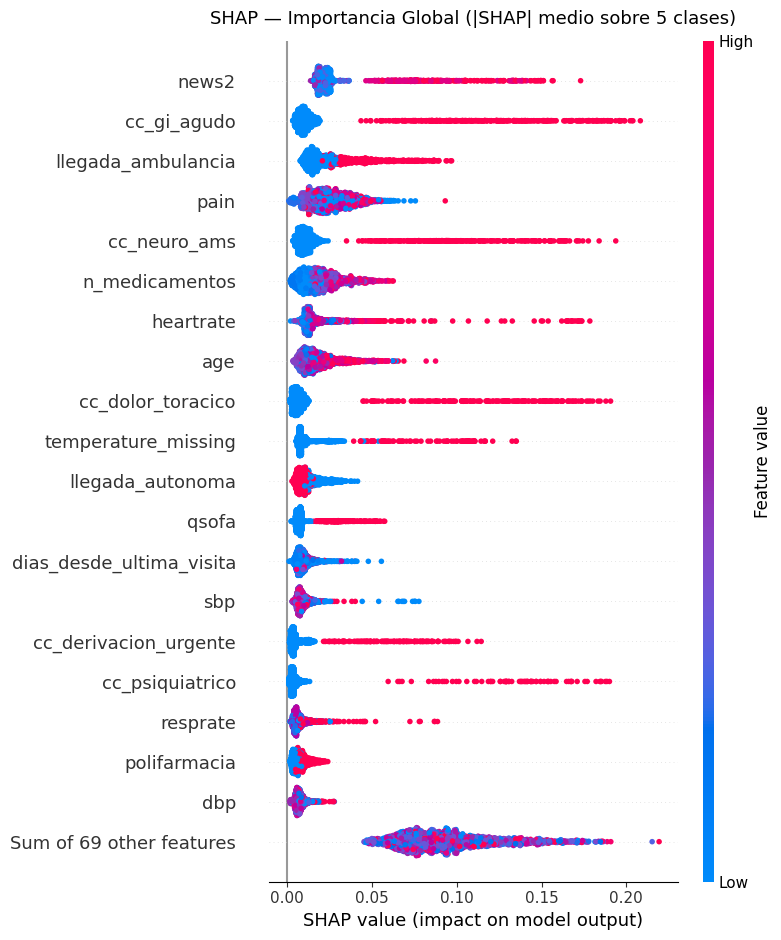

✓ Figura guardada: fase0_shap_beeswarm_fix.png


In [20]:
# ── Beeswarm global (SHAP 0.49 API) ──────────────────────────────────────────
# FIX: usar |SHAP| antes de promediar sobre clases, igual que importancia_global
shap_mean_clases = np.abs(sv).mean(axis=2)  # (n, 88): magnitud media sobre clases

expl_global = shap.Explanation(
    values        = shap_mean_clases,
    data          = X_shap_np,
    feature_names = feature_names
)

plt.figure(figsize=(10, 9))
shap.plots.beeswarm(expl_global, max_display=20, show=False)
plt.title("SHAP — Importancia Global (|SHAP| medio sobre 5 clases)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("fase0_shap_beeswarm_fix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada: fase0_shap_beeswarm_fix.png")

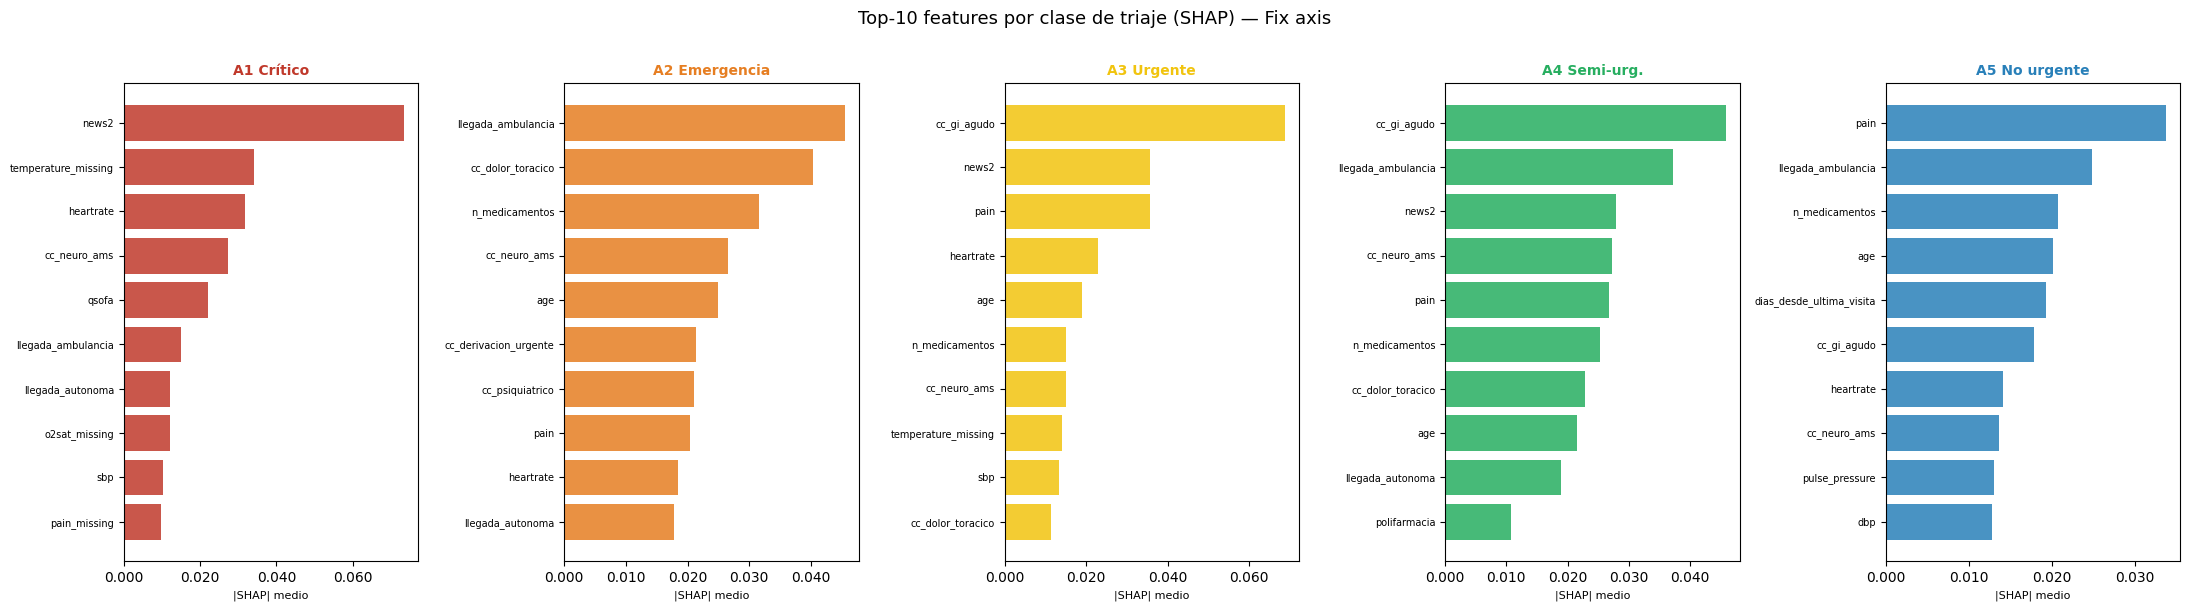

✓ Figura guardada: fase0_shap_por_clase_fix.png


In [21]:
# ── Importancia por clase (top-10 cada una) ────────────────────────────────────
nombres_clase = ["A1 Crítico", "A2 Emergencia", "A3 Urgente", "A4 Semi-urg.", "A5 No urgente"]
colores_clase = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)

for c, (ax, nombre, color) in enumerate(zip(axes, nombres_clase, colores_clase)):
    imp_c = pd.Series(
        np.abs(sv[:, :, c]).mean(axis=0),
        index=feature_names
    ).sort_values(ascending=False).head(10)
    ax.barh(imp_c.index[::-1], imp_c.values[::-1], color=color, alpha=0.85)
    ax.set_title(nombre, fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("|SHAP| medio", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

plt.suptitle("Top-10 features por clase de triaje (SHAP) — Fix axis", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fase0_shap_por_clase_fix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada: fase0_shap_por_clase_fix.png")

Total features: 88

Rank  Feature                                            |SHAP|
-----------------------------------------------------------------
   1  news2                                            0.032791
   2  cc_gi_agudo                                      0.030019
   3  llegada_ambulancia                               0.026356
   4  pain                                             0.025253
   5  cc_neuro_ams                                     0.021980
   6  n_medicamentos                                   0.019318
   7  heartrate                                        0.019201
   8  age                                              0.018451
   9  cc_dolor_toracico                                0.016705
  10  temperature_missing                              0.013672
  11  llegada_autonoma                                 0.012310
  12  qsofa                                            0.010329
  13  dias_desde_ultima_visita                         0.009848
  14  sbp         

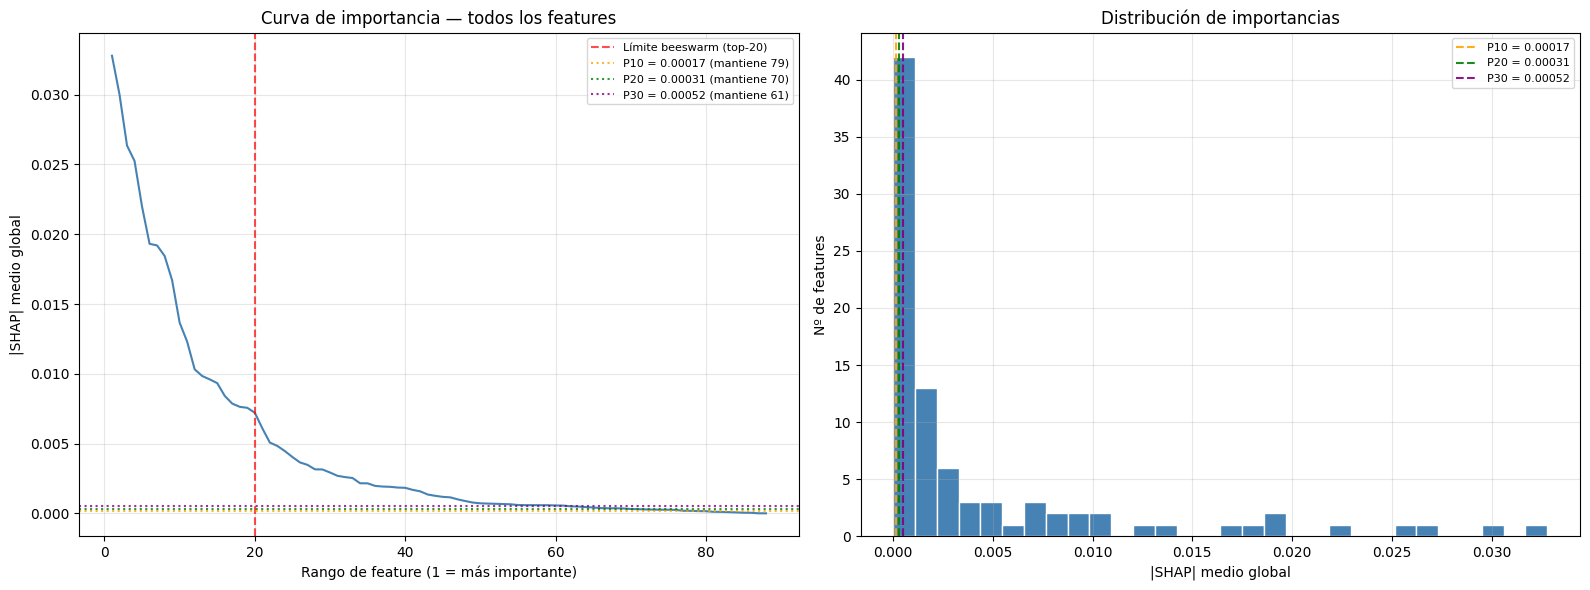

✓ fase0_shap_importancia_distribucion.png guardada

Resumen: cuántos features quedan según umbral de corte
Criterio                            Umbral   Features eliminadas  Features restantes
-------------------------------------------------------------------------------------
Percentil 5                        0.000087                     5                  83
Percentil 10                       0.000170                     9                  79
Percentil 15                       0.000269                    14                  74
Percentil 20                       0.000315                    18                  70
Percentil 25                       0.000384                    22                  66
Percentil 30                       0.000520                    27                  61
|SHAP| < 0.001                    0.001000                    41                  47
|SHAP| < 0.002                    0.002000                    53                  35
|SHAP| < 0.003                    0.

In [22]:
# ── Diagnóstico completo de la distribución de importancia SHAP ──────────────
# Objetivo: ver el "codo" real antes de decidir umbral de pruning.
# El beeswarm solo muestra top-20; aquí inspeccionamos las 69 restantes.
n_features_total = len(importancia_global)
print(f"Total features: {n_features_total}")
print(f"\n{'Rank':>4}  {'Feature':<45}  {'|SHAP|':>10}")
print("-" * 65)
for rank, (feat, val) in enumerate(importancia_global.items(), start=1):
    marker = " ◄" if rank == 20 else ""  # marca el límite del beeswarm
    print(f"{rank:>4}  {feat:<45}  {val:>10.6f}{marker}")
# ── Gráfico 1: Curva de importancia (todos los features ordenados) ────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Panel izquierdo: valor de importancia por rango
axes[0].plot(range(1, n_features_total + 1), importancia_global.values,
             color='steelblue', linewidth=1.5)
axes[0].axvline(20, color='red', linestyle='--', alpha=0.7, label='Límite beeswarm (top-20)')
# Marcar percentiles clave
for pct, color in [(10, 'orange'), (20, 'green'), (30, 'purple')]:
    val_pct = importancia_global.quantile(pct / 100)
    n_pct = (importancia_global > val_pct).sum()
    axes[0].axhline(val_pct, color=color, linestyle=':', alpha=0.8,
                    label=f'P{pct} = {val_pct:.5f} (mantiene {n_pct})')
axes[0].set_xlabel("Rango de feature (1 = más importante)")
axes[0].set_ylabel("|SHAP| medio global")
axes[0].set_title("Curva de importancia — todos los features")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
# Panel derecho: histograma de la distribución
axes[1].hist(importancia_global.values, bins=30, color='steelblue', edgecolor='white')
for pct, color in [(10, 'orange'), (20, 'green'), (30, 'purple')]:
    val_pct = importancia_global.quantile(pct / 100)
    axes[1].axvline(val_pct, color=color, linestyle='--', alpha=0.9,
                    label=f'P{pct} = {val_pct:.5f}')
axes[1].set_xlabel("|SHAP| medio global")
axes[1].set_ylabel("Nº de features")
axes[1].set_title("Distribución de importancias")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fase0_shap_importancia_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ fase0_shap_importancia_distribucion.png guardada")
# ── Resumen cuantitativo por percentil ───────────────────────────────────────
print("\nResumen: cuántos features quedan según umbral de corte")
print(f"{'Criterio':<30}  {'Umbral':>10}  {'Features eliminadas':>20}  {'Features restantes':>18}")
print("-" * 85)
for pct in [5, 10, 15, 20, 25, 30]:
    val = importancia_global.quantile(pct / 100)
    eliminadas = (importancia_global <= val).sum()
    restantes = n_features_total - eliminadas
    print(f"Percentil {pct:<21}  {val:>10.6f}  {eliminadas:>20}  {restantes:>18}")
# Umbral absoluto alternativo: features con |SHAP| < 0.001
for thr in [0.001, 0.002, 0.003]:
    eliminadas = (importancia_global < thr).sum()
    restantes = n_features_total - eliminadas
    print(f"|SHAP| < {thr:<21}  {thr:>10.6f}  {eliminadas:>20}  {restantes:>18}")

In [9]:
# ── Decisión de pruning: features con SHAP muy bajo ──────────────────────────
# Umbral: percentil 10 de importancia global
umbral_p10 = importancia_global.quantile(0.10)
candidatas_pruning = importancia_global[importancia_global <= umbral_p10].index.tolist()

print(f"Umbral percentil 10 : {umbral_p10:.6f}")
print(f"Features candidatas a eliminar ({len(candidatas_pruning)}):")
for f in candidatas_pruning:
    print(f"  {f:40s}  |SHAP|={importancia_global[f]:.6f}")

# Guardar para usar en Fase 1
FEATURES_EXCLUIR_PRUNING = candidatas_pruning
print("\n→ Variable FEATURES_EXCLUIR_PRUNING disponible para Fase 1.")

Umbral percentil 10 : 0.000170
Features candidatas a eliminar (9):
  med_inmunosupresor                        |SHAP|=0.000166
  shock_oculto_anciano                      |SHAP|=0.000122
  fiebre                                    |SHAP|=0.000116
  hipertension_severa                       |SHAP|=0.000100
  qsofa_positivo                            |SHAP|=0.000080
  med_digoxina                              |SHAP|=0.000056
  med_antiaritmico                          |SHAP|=0.000049
  shock_index_severo                        |SHAP|=0.000015
  llegada_helicoptero                       |SHAP|=0.000011

→ Variable FEATURES_EXCLUIR_PRUNING disponible para Fase 1.


In [23]:
# ── Decisión de pruning: umbral basado en análisis de distribución ────────────
# Diagnóstico previo revela dos zonas claras:
#   - Top 47 features: |SHAP| >= 0.001  →  contribución real
#   - Cola 41 features: |SHAP| < 0.001  →  redundantes con vars continuas
# P10=0.000170 era demasiado conservador (solo 9 features). Usamos umbral absoluto.

UMBRAL_SHAP = 0.001

candidatas_pruning = importancia_global[importancia_global < UMBRAL_SHAP].index.tolist()
features_retenidas = importancia_global[importancia_global >= UMBRAL_SHAP].index.tolist()

print(f"Umbral |SHAP| < {UMBRAL_SHAP}")
print(f"Features eliminadas : {len(candidatas_pruning)}")
print(f"Features retenidas  : {len(features_retenidas)}")
print("\nEliminadas (redundantes o ruido):")
for f in candidatas_pruning:
    print(f"  {f:<45}  {importancia_global[f]:.6f}")

# Excepciones clínicas: features que se fuerzan aunque estén bajo el umbral SHAP
# Añadir aquí cualquier variable con justificación clínica explícita
FEATURES_FORZAR = [
    # "o2sat_bajo_92",   # EPOC: umbral clínico diferente al de población general
    # "taquipnea_grave", # Deterioro respiratorio: redundante con resprate pero umbral binario útil
]

if FEATURES_FORZAR:
    candidatas_pruning = [f for f in candidatas_pruning if f not in FEATURES_FORZAR]
    features_retenidas = features_retenidas + FEATURES_FORZAR
    print(f"\n⚠ Excepciones clínicas forzadas: {FEATURES_FORZAR}")

# Variable disponible para Fase 1+
FEATURES_EXCLUIR_PRUNING = candidatas_pruning

print(f"\n→ FEATURES_EXCLUIR_PRUNING: {len(FEATURES_EXCLUIR_PRUNING)} features excluidas.")
print(f"→ Conjunto activo para Fase 1: {len(features_retenidas)} features.")

Umbral |SHAP| < 0.001
Features eliminadas : 41
Features retenidas  : 47

Eliminadas (redundantes o ruido):
  anciano_mayor                                  0.000892
  med_diuretico_asa                              0.000784
  hx_digestivo                                   0.000729
  med_respiratorio_inhalado                      0.000711
  med_ssri_snri                                  0.000695
  med_anticoagulante                             0.000679
  med_ace_ara2                                   0.000660
  med_diuretico_tiazida                          0.000608
  alto_riesgo_delirium                           0.000596
  med_benzodiacepina                             0.000596
  o2sat_bajo_92                                  0.000594
  vitales_criticos                               0.000593
  hx_respiratorio                                0.000576
  med_anticonvulsivante                          0.000567
  hx_neuro                                       0.000515
  riesgo_depresion_resp

---
## FASE 1 — Nuevas Features de Interacción

### Fundamento (SHAP guía la elección)
Los 5 features más importantes globalmente según SHAP son:
1. `news2` — score fisiológico compuesto
2. `cc_gi_agudo` — síndrome GI agudo
3. `llegada_ambulancia` — proxy de gravedad percibida pre-hospitalaria
4. `pain` — dolor auto-reportado  
5. `cc_neuro_ams` — alteración neurológica

**Interacciones propuestas** (multiplicativas — los árboles las pueden aprender pero requieren más profundidad sin ellas):

| Feature nueva | Fórmula | Justificación clínica |
|---|---|---|
| `news2_x_ambulancia` | `news2 × llegada_ambulancia` | Score fisiológico alto + llegada en ambulancia = triage crítico casi seguro |
| `age_x_shock_alto` | `age × shock_index_alto` | Anciano en shock tiene mortalidad multiplicada (presentación atípica) |
| `vitales_x_meds` | `n_vitales_anomalos × n_medicamentos` | Comorbilidad crónica + descompensación aguda |
| `neuro_x_pain_miss` | `cc_neuro_ams × pain_missing` | AMS + incapacidad de reportar dolor = proxy ventilación comprometida |

**Variables temporales cíclicas** (evaluadas con Kruskal-Wallis antes de incluir).

In [24]:
def añadir_features_interaccion(X: pd.DataFrame) -> pd.DataFrame:
    """
    Bloque 7: 4 features de interacción clínicamente motivadas.
    Aplica sobre cualquier DataFrame que tenga las 88 features base.
    """
    df = X.copy()

    # news2 × llegada_ambulancia
    df["news2_x_ambulancia"] = (
        df["news2"].fillna(0) * df["llegada_ambulancia"].fillna(0)
    ).astype("float32")

    # age × shock_index_alto
    df["age_x_shock_alto"] = (
        df["age"].fillna(0) * df["shock_index_alto"].fillna(0)
    ).astype("float32")

    # n_vitales_anomalos × n_medicamentos
    df["vitales_x_meds"] = (
        df["n_vitales_anomalos"].fillna(0) * df["n_medicamentos"].fillna(0)
    ).astype("float32")

    # cc_neuro_ams × pain_missing
    df["neuro_x_pain_miss"] = (
        df["cc_neuro_ams"].fillna(0) * df["pain_missing"].fillna(0)
    ).astype("int8")

    return df

FEATURES_INTERACCION = [
    "news2_x_ambulancia", "age_x_shock_alto", "vitales_x_meds", "neuro_x_pain_miss"
]

print(f"Features de interacción definidas: {FEATURES_INTERACCION}")

Features de interacción definidas: ['news2_x_ambulancia', 'age_x_shock_alto', 'vitales_x_meds', 'neuro_x_pain_miss']


In [25]:
# ── Kruskal-Wallis de las 4 interacciones vs acuity ──────────────────────────
# Justificación empírica: solo incluir si H es significativo

X_train_check = añadir_features_interaccion(X_train)

print(f"{'Feature':<30} {'H-stat':>10} {'p-value':>12} {'Incluir?':>10}")
print("-" * 68)
for feat in FEATURES_INTERACCION:
    grupos = [X_train_check.loc[y_train == k, feat].dropna().values
              for k in sorted(y_train.unique())]
    grupos = [g for g in grupos if len(g) > 0]
    h_stat, p_val = kruskal(*grupos)
    incluir = "✓ SÍ" if p_val < 0.001 else "✗ NO"
    print(f"{feat:<30} {h_stat:>10.1f} {p_val:>12.2e} {incluir:>10}")

Feature                            H-stat      p-value   Incluir?
--------------------------------------------------------------------
news2_x_ambulancia                21807.6     0.00e+00       ✓ SÍ
age_x_shock_alto                  14601.0     0.00e+00       ✓ SÍ
vitales_x_meds                     8214.6     0.00e+00       ✓ SÍ
neuro_x_pain_miss                 12856.4     0.00e+00       ✓ SÍ


In [26]:
# ── Variables temporales cíclicas — Kruskal-Wallis ────────────────────────────
# Requiere intime del dataset limpio. Evaluamos el H antes de decidir si incluir.

try:
    df_clean = pd.read_parquet(
        DATA_INTERIM / "dataset_clean.parquet",
        columns=["stay_id", "intime"]
    )
    df_feat = pd.read_parquet(DATA_PROCESSED / "dataset_features.parquet")

    # Reconstruir intime sobre train+test con stay_id como clave
    # dataset_features no tiene stay_id; usamos índice temporal del split
    # NOTA: dataset_features tiene el mismo orden que X_train+X_test concatenados
    n_total = len(df_feat)
    n_train = len(X_train)

    # Merge por posición (mismo orden garantizado por el split temporal de 05_features)
    intime_all = df_clean.set_index("stay_id").reindex(df_feat.index)["intime"] \
        if "stay_id" in df_feat.columns else None

    if intime_all is None:
        # Alternativa: reconstruir intime directamente desde dataset_clean
        print("dataset_features no tiene stay_id — cargando intime desde dataset_clean directo")
        df_clean_full = pd.read_parquet(DATA_INTERIM / "dataset_clean.parquet")
        fecha_corte   = df_clean_full["intime"].quantile(0.80)
        intime_train  = df_clean_full.loc[df_clean_full["intime"] <= fecha_corte, "intime"].reset_index(drop=True)
    else:
        intime_train = intime_all.iloc[:n_train].reset_index(drop=True)

    # Codificación cíclica hora de llegada
    hora = pd.to_datetime(intime_train).dt.hour
    hora_sin = np.sin(2 * np.pi * hora / 24)
    hora_cos = np.cos(2 * np.pi * hora / 24)

    # y_train alineado por posición
    y_tr_pos = y_train.reset_index(drop=True)

    for nombre, vals in [("hora_sin", hora_sin), ("hora_cos", hora_cos)]:
        grupos = [vals[y_tr_pos == k].dropna().values for k in sorted(y_tr_pos.unique())]
        h_stat, p_val = kruskal(*[g for g in grupos if len(g) > 0])
        incluir = "✓ SÍ" if p_val < 0.001 else "✗ NO (descartar)"
        print(f"{nombre:<30} H={h_stat:>8.1f}  p={p_val:.2e}  {incluir}")

except Exception as e:
    print(f"No se pudo evaluar variables temporales: {e}")
    print("→ Requiere dataset_clean.parquet con intime. Continuar sin ellas.")

dataset_features no tiene stay_id — cargando intime desde dataset_clean directo
hora_sin                       H=   577.3  p=1.26e-123  ✓ SÍ
hora_cos                       H=    29.6  p=5.92e-06  ✓ SÍ


In [27]:
# ── Construir X_train_v2 y X_test_v2 ────────────────────────────────────────
# v2 = 88 features originales + 4 interacciones
# Excluimos también las features con SHAP muy bajo (FEATURES_EXCLUIR_PRUNING)

X_train_v2 = añadir_features_interaccion(X_train)
X_test_v2  = añadir_features_interaccion(X_test)

TODAS_FEATURES_V2 = TODAS_FEATURES + FEATURES_INTERACCION
print(f"Features v2: {len(TODAS_FEATURES_V2)} (88 originales + {len(FEATURES_INTERACCION)} interacciones)")
print(f"Shape X_train_v2: {X_train_v2.shape}  |  X_test_v2: {X_test_v2.shape}")

Features v2: 92 (88 originales + 4 interacciones)
Shape X_train_v2: (334480, 92)  |  X_test_v2: (83620, 92)


In [28]:
# ── Helper: construir pipeline RF estándar ────────────────────────────────────
def build_rf_pipeline(features_cont, features_bin, features_cat,
                       rf_params: dict | None = None):
    """
    Pipeline RF con imputación mediana/moda y OrdinalEncoder para categóricas.
    rf_params: parámetros del RandomForestClassifier (si None usa los de Optuna).
    """
    if rf_params is None:
        with open(DATA_PROCESSED / "mejores_parametros_rf.json") as f:
            rf_params = json.load(f)["mejores_parametros"]

    prepro = ColumnTransformer([
        ("cont", SimpleImputer(strategy="median"),        features_cont),
        ("bin",  SimpleImputer(strategy="most_frequent"), features_bin),
        ("cat",  Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), features_cat),
    ], remainder="drop")

    clf = RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
        **rf_params
    )
    return Pipeline([("prepro", prepro), ("clf", clf)])


def cv_macro_f1(pipeline, X, y, groups, n_splits=3):
    """CV estratificada por grupo. Devuelve (media, std) de Macro F1."""
    cv  = StratifiedGroupKFold(n_splits=n_splits, shuffle=False)
    scores = []
    for fold, (tr, val) in enumerate(cv.split(X, y, groups)):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]
        w_tr = compute_sample_weight("balanced", y_tr)
        pipe = clone(pipeline)
        pipe.fit(X_tr, y_tr, clf__sample_weight=w_tr)
        y_val_pred = pipe.predict(X_val)
        scores.append(f1_score(y_val, y_val_pred, average="macro", zero_division=0))
        print(f"  Fold {fold+1}: {scores[-1]:.4f}")
    return np.mean(scores), np.std(scores)

print("Helpers definidos.")

Helpers definidos.


In [29]:
# ── Experimento 01: RF Optuna con features v2 (interacciones) ─────────────────
print("=" * 60)
print("Experimento 01 — RF Optuna + features de interacción (v2)")
print("=" * 60)

features_cont_v2 = FEATURES_CONT + ["news2_x_ambulancia", "age_x_shock_alto", "vitales_x_meds"]
features_bin_v2  = FEATURES_BIN  + ["neuro_x_pain_miss"]

pipe_v2 = build_rf_pipeline(features_cont_v2, features_bin_v2, FEATURES_CAT)

print("\nCV 3-fold (rápido para exploración):")
cv_mean_v2, cv_std_v2 = cv_macro_f1(pipe_v2, X_train_v2, y_train, groups_train, n_splits=3)
print(f"\nCV Macro F1 v2: {cv_mean_v2:.4f} ± {cv_std_v2:.4f}")
print(f"Δ vs baseline (CV 0.5013): {cv_mean_v2 - 0.5013:+.4f}")

# Refit sobre train completo y evaluar en test
pipe_v2.fit(X_train_v2, y_train, clf__sample_weight=sample_weights_train)
y_pred_v2 = pipe_v2.predict(X_test_v2)
m_f1, r_a1, f1_a4, f1_a5 = report_scores(y_test, y_pred_v2)

print(f"\nTest Macro F1     : {m_f1:.4f}  (baseline: 0.4946)")
print(f"Test Recall A1    : {r_a1:.4f}  (baseline: 0.680)")
print(f"Test F1 A4        : {f1_a4:.4f}  (baseline: 0.386)")
print(f"Test F1 A5        : {f1_a5:.4f}  (baseline: 0.094)")

registrar("01_RF + Features Interacción (v2)", macro_f1_cv=cv_mean_v2,
          macro_f1_test=m_f1, recall_a1=r_a1, f1_a4=f1_a4, f1_a5=f1_a5,
          notas="+4 features interacción: news2×amb, age×shock, vitales×meds, neuro×pain_miss")
resultados

Experimento 01 — RF Optuna + features de interacción (v2)

CV 3-fold (rápido para exploración):
  Fold 1: 0.3980
  Fold 2: 0.3980
  Fold 3: 0.4063

CV Macro F1 v2: 0.4008 ± 0.0039
Δ vs baseline (CV 0.5013): -0.1005

Test Macro F1     : 0.4041  (baseline: 0.4946)
Test Recall A1    : 0.7442  (baseline: 0.680)
Test F1 A4        : 0.2828  (baseline: 0.386)
Test F1 A5        : 0.0201  (baseline: 0.094)


,Experimento,Macro_F1_CV,Macro_F1_Test,Recall_A1,F1_A4,F1_A5,Notas
0,00_Baseline RF Optuna (06_models),0.5013,0.4946,0.6803,0.3862,0.0940,"n_est=799, max_depth=36, max_features=0.42"
1,01_RF + Features Interacción (v2),0.4008,0.4041,0.7442,0.2828,0.0201,"+4 features interacción: news2×amb, age×shock,..."


---
## FASE 2 — MICE (imputación) + SMOTENC (oversampling)

### 2a — MICE (IterativeImputer)
La imputación por mediana asume independencia entre vitales.  
MICE usa regresión iterativa (BayesianRidge por defecto) capturando correlaciones entre variables.

### 2b — SMOTENC
Clase 5 (F1=0.094) y clase 4 (F1=0.386) son casi indetectables.  
`SMOTENC` genera ejemplos sintéticos respetando columnas categóricas (gender).  
**Crítico**: aplicar SMOTENC **dentro del CV**, no fuera, para evitar data leakage.

In [ ]:
# ── Instalar imbalanced-learn si no está disponible ───────────────────────────
try:
    import imblearn
    print(f"imbalanced-learn ya instalado: {imblearn.__version__}")
except ImportError:
    print("Instalando imbalanced-learn...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "imbalanced-learn"], check=True)
    import imblearn
    print(f"imbalanced-learn instalado: {imblearn.__version__}")

In [ ]:
# ── 2a: Experimento MICE ─────────────────────────────────────────────────────
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

def build_rf_pipeline_mice(features_cont, features_bin, features_cat,
                            rf_params: dict | None = None):
    """Pipeline RF con MICE en lugar de mediana para features continuas."""
    if rf_params is None:
        with open(DATA_PROCESSED / "mejores_parametros_rf.json") as f:
            rf_params = json.load(f)["mejores_parametros"]

    prepro = ColumnTransformer([
        ("cont", IterativeImputer(estimator=BayesianRidge(),
                                  max_iter=10, random_state=42,
                                  skip_complete=True),       features_cont),
        ("bin",  SimpleImputer(strategy="most_frequent"),   features_bin),
        ("cat",  Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), features_cat),
    ], remainder="drop")

    clf = RandomForestClassifier(
        class_weight="balanced", n_jobs=-1, random_state=42, **rf_params
    )
    return Pipeline([("prepro", prepro), ("clf", clf)])


print("=" * 60)
print("Experimento 02 — RF + MICE (features v2)")
print("=" * 60)

pipe_mice = build_rf_pipeline_mice(features_cont_v2, features_bin_v2, FEATURES_CAT)

print("\nCV 3-fold:")
cv_mean_mice, cv_std_mice = cv_macro_f1(pipe_mice, X_train_v2, y_train,
                                         groups_train, n_splits=3)
print(f"\nCV Macro F1 MICE: {cv_mean_mice:.4f} ± {cv_std_mice:.4f}")
print(f"Δ vs v2 (CV {cv_mean_v2:.4f}): {cv_mean_mice - cv_mean_v2:+.4f}")

pipe_mice.fit(X_train_v2, y_train, clf__sample_weight=sample_weights_train)
y_pred_mice = pipe_mice.predict(X_test_v2)
m_f1, r_a1, f1_a4, f1_a5 = report_scores(y_test, y_pred_mice)

registrar("02_RF + MICE (v2)", macro_f1_cv=cv_mean_mice,
          macro_f1_test=m_f1, recall_a1=r_a1, f1_a4=f1_a4, f1_a5=f1_a5,
          notas="IterativeImputer(BayesianRidge, max_iter=10) para vitales continuos")
resultados

In [ ]:
# ── 2b: Experimento SMOTENC ──────────────────────────────────────────────────
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

def cv_macro_f1_smote(rf_params, X, y, groups, n_splits=3):
    """
    CV con SMOTENC aplicado DENTRO de cada fold (anti-leakage).
    Imputa mediana primero (SMOTENC requiere sin NaN), luego sobremuestrea.
    """
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=False)
    scores = []

    # Índice de la columna categórica 'gender' en X (después de features v2)
    gender_idx = X.columns.get_loc("gender")

    for fold, (tr, val) in enumerate(cv.split(X, y, groups)):
        X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
        y_tr, y_val = y.iloc[tr], y.iloc[val]

        # Paso 1: imputación antes de SMOTENC (no admite NaN)
        imp_cont = SimpleImputer(strategy="median")
        imp_bin  = SimpleImputer(strategy="most_frequent")
        prepro_temp = ColumnTransformer([
            ("cont", imp_cont, features_cont_v2),
            ("bin",  imp_bin,  features_bin_v2 + FEATURES_CAT),
        ], remainder="drop")
        X_tr_imp  = prepro_temp.fit_transform(X_tr)
        X_val_imp = prepro_temp.transform(X_val)

        # El índice de gender cambia tras ColumnTransformer — es la última columna de bin
        n_cont = len(features_cont_v2)
        n_bin  = len(features_bin_v2)
        gender_idx_imp = n_cont + n_bin  # última columna (después de continuas + binarias)

        # Paso 2: SMOTENC solo dentro del fold de entrenamiento
        smote = SMOTENC(
            categorical_features=[gender_idx_imp],
            sampling_strategy={5: min(2000, 5 * (y_tr == 5).sum() + 1),
                                4: min(10000, 2 * (y_tr == 4).sum())},
            k_neighbors=5,
            random_state=42
        )
        try:
            X_tr_res, y_tr_res = smote.fit_resample(X_tr_imp, y_tr)
        except Exception as e:
            print(f"  Fold {fold+1} SMOTENC error: {e} — usando datos sin oversample")
            X_tr_res, y_tr_res = X_tr_imp, y_tr

        # Paso 3: entrenar RF sobre datos remuestreados
        clf = RandomForestClassifier(
            class_weight="balanced", n_jobs=-1, random_state=42, **rf_params
        )
        w_res = compute_sample_weight("balanced", y_tr_res)
        clf.fit(X_tr_res, y_tr_res, sample_weight=w_res)

        y_val_pred = clf.predict(X_val_imp)
        scores.append(f1_score(y_val, y_val_pred, average="macro", zero_division=0))
        print(f"  Fold {fold+1}: {scores[-1]:.4f}  (train: {len(y_tr)} → {len(y_tr_res)})")

    return np.mean(scores), np.std(scores)


print("=" * 60)
print("Experimento 03 — RF + SMOTENC clases 4 y 5 (dentro de CV)")
print("=" * 60)

with open(DATA_PROCESSED / "mejores_parametros_rf.json") as f:
    RF_PARAMS = json.load(f)["mejores_parametros"]

cv_mean_smote, cv_std_smote = cv_macro_f1_smote(
    RF_PARAMS, X_train_v2, y_train, groups_train, n_splits=3
)
print(f"\nCV Macro F1 SMOTENC: {cv_mean_smote:.4f} ± {cv_std_smote:.4f}")
print(f"Δ vs v2 (CV {cv_mean_v2:.4f}): {cv_mean_smote - cv_mean_v2:+.4f}")

# Refit completo (imputar + SMOTENC + entrenar)
# Para el test final usamos el prepro del pipe_v2 (ya fiteado sobre train completo)
imp_full = ColumnTransformer([
    ("cont", SimpleImputer(strategy="median"),        features_cont_v2),
    ("bin",  SimpleImputer(strategy="most_frequent"), features_bin_v2 + FEATURES_CAT),
], remainder="drop")
X_tr_full_imp = imp_full.fit_transform(X_train_v2)
X_te_full_imp = imp_full.transform(X_test_v2)

n_cont_v2 = len(features_cont_v2)
gender_final_idx = n_cont_v2 + len(features_bin_v2)

smote_full = SMOTENC(
    categorical_features=[gender_final_idx],
    sampling_strategy={5: min(2000, 5 * (y_train == 5).sum() + 1),
                       4: min(10000, 2 * (y_train == 4).sum())},
    k_neighbors=5, random_state=42
)
X_tr_smote, y_tr_smote = smote_full.fit_resample(X_tr_full_imp, y_train)
print(f"\nTrain antes SMOTENC: {len(y_train)} | después: {len(y_tr_smote)}")
print(f"Distribución tras SMOTENC:")
print(pd.Series(y_tr_smote).value_counts().sort_index().to_string())

clf_smote = RandomForestClassifier(
    class_weight="balanced", n_jobs=-1, random_state=42, **RF_PARAMS
)
clf_smote.fit(X_tr_smote, y_tr_smote,
              sample_weight=compute_sample_weight("balanced", y_tr_smote))

y_pred_smote = clf_smote.predict(X_te_full_imp)
m_f1, r_a1, f1_a4, f1_a5 = report_scores(y_test, y_pred_smote)

print(f"\nTest Macro F1  : {m_f1:.4f}")
print(f"Test Recall A1 : {r_a1:.4f}")
print(f"Test F1 A4     : {f1_a4:.4f}")
print(f"Test F1 A5     : {f1_a5:.4f}")

registrar("03_RF + SMOTENC (v2)", macro_f1_cv=cv_mean_smote,
          macro_f1_test=m_f1, recall_a1=r_a1, f1_a4=f1_a4, f1_a5=f1_a5,
          notas="SMOTENC dentro de CV. A4: ×2, A5: ×5 muestras sintéticas")
resultados

---
## FASE 3 — Clasificación Ordinal (Frank & Hall 2001)

### Fundamento teórico
`acuity` es **ordinal**: 1 > 2 > 3 > 4 > 5. Un clasificador nominal (softmax o Gini) no sabe que "predecir 3 cuando es 2" es menos grave que "predecir 5 cuando es 2".  

**Descomposición Frank & Hall**: entrenar K-1 = 4 clasificadores binarios acumulativos:  
- clf_1: P(Y ≤ 1) — ¿es el paciente crítico?  
- clf_2: P(Y ≤ 2) — ¿es crítico o emergencia?  
- clf_3: P(Y ≤ 3) — ¿es urgente o menos?  
- clf_4: P(Y ≤ 4) — ¿es semi-urgente o menos?  

Recuperación de probabilidades: `P(Y=k) = P(Y≤k) - P(Y≤k-1)`.  
Compatible con **cualquier estimador** sklearn → usa el RF Optuna como base.

In [ ]:
class OrdinalClassifier:
    """
    Clasificación ordinal por descomposición Frank & Hall (2001).
    Entrena K-1 clasificadores binarios acumulativos P(Y<=k).
    Referencia: Frank, E. & Hall, M. (2001). ECML.
    """

    def __init__(self, base_estimator):
        self.base_estimator = base_estimator
        self.classifiers_   = []
        self.classes_        = None

    def fit(self, X, y, use_balanced_weights=True):
        self.classes_ = np.sort(np.unique(y))
        K = len(self.classes_)
        self.classifiers_ = []

        for k in range(K - 1):  # K-1 clasificadores
            threshold = self.classes_[k]
            y_bin = (y <= threshold).astype(int)
            clf   = clone(self.base_estimator)
            if use_balanced_weights:
                # Recalcular pesos balanceados para el subproblema binario
                w_bin = compute_sample_weight("balanced", y_bin)
                clf.fit(X, y_bin, sample_weight=w_bin)
            else:
                clf.fit(X, y_bin)
            self.classifiers_.append(clf)
            print(f"  clf_{k+1} (P(Y<={threshold})) entrenado — "
                  f"positivos: {y_bin.sum():,} / {len(y_bin):,}")
        return self

    def predict_proba(self, X):
        K = len(self.classes_)
        # Probabilidades acumulativas P(Y <= k)
        cum = np.zeros((X.shape[0], K))
        for k, clf in enumerate(self.classifiers_):
            cum[:, k] = clf.predict_proba(X)[:, 1]
        cum[:, K - 1] = 1.0  # P(Y <= máx) = 1

        # P(Y = k) = P(Y<=k) - P(Y<=k-1)
        proba = np.zeros_like(cum)
        proba[:, 0] = cum[:, 0]
        for k in range(1, K):
            proba[:, k] = cum[:, k] - cum[:, k - 1]

        # Clip y renormalizar (garantiza distribución válida)
        proba = np.clip(proba, 1e-9, None)
        proba /= proba.sum(axis=1, keepdims=True)
        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

print("OrdinalClassifier definido.")

In [ ]:
# ── Preprocesamiento único (mediana + OrdinalEncoder) sobre v2 ─────────────────
# OrdinalClassifier trabaja con arrays numpy → preprocesamos una vez

prepro_v2 = ColumnTransformer([
    ("cont", SimpleImputer(strategy="median"),        features_cont_v2),
    ("bin",  SimpleImputer(strategy="most_frequent"), features_bin_v2),
    ("cat",  Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), FEATURES_CAT),
], remainder="drop")

X_train_v2_np = prepro_v2.fit_transform(X_train_v2)
X_test_v2_np  = prepro_v2.transform(X_test_v2)

print(f"X_train_v2_np: {X_train_v2_np.shape}")
print(f"X_test_v2_np : {X_test_v2_np.shape}")

In [ ]:
# ── CV 3-fold para OrdinalClassifier ─────────────────────────────────────────
print("=" * 60)
print("Experimento 04 — RF Ordinal (Frank & Hall)")
print("=" * 60)

# Estimador base: RF con params Optuna (sin class_weight, lo maneja el OrdinalClassifier)
rf_base_ordinal = RandomForestClassifier(
    n_estimators   = RF_PARAMS["n_estimators"],
    max_depth      = RF_PARAMS["max_depth"],
    max_features   = RF_PARAMS["max_features"],
    min_samples_split = RF_PARAMS["min_samples_split"],
    min_samples_leaf  = RF_PARAMS["min_samples_leaf"],
    n_jobs=-1, random_state=42
)

cv_ord  = StratifiedGroupKFold(n_splits=3, shuffle=False)
scores_ord = []

for fold, (tr, val) in enumerate(cv_ord.split(X_train_v2_np, y_train, groups_train)):
    X_tr_f = X_train_v2_np[tr]
    X_val_f = X_train_v2_np[val]
    y_tr_f  = y_train.iloc[tr]
    y_val_f = y_train.iloc[val]

    print(f"\nFold {fold+1}:")
    ord_clf = OrdinalClassifier(rf_base_ordinal)
    ord_clf.fit(X_tr_f, y_tr_f, use_balanced_weights=True)
    y_val_pred = ord_clf.predict(X_val_f)
    fold_f1 = f1_score(y_val_f, y_val_pred, average="macro", zero_division=0)
    scores_ord.append(fold_f1)
    print(f"  Macro F1: {fold_f1:.4f}")

cv_mean_ord = np.mean(scores_ord)
cv_std_ord  = np.std(scores_ord)
print(f"\nCV Macro F1 Ordinal: {cv_mean_ord:.4f} ± {cv_std_ord:.4f}")
print(f"Δ vs v2 (CV {cv_mean_v2:.4f}): {cv_mean_ord - cv_mean_v2:+.4f}")

In [ ]:
# ── Refit ordinal sobre train completo + evaluación test ──────────────────────
print("Entrenando OrdinalClassifier sobre train completo...")
ord_final = OrdinalClassifier(rf_base_ordinal)
ord_final.fit(X_train_v2_np, y_train, use_balanced_weights=True)

y_pred_ord = ord_final.predict(X_test_v2_np)
m_f1, r_a1, f1_a4, f1_a5 = report_scores(y_test, y_pred_ord)

print(f"\nTest Macro F1  : {m_f1:.4f}")
print(f"Test Recall A1 : {r_a1:.4f}")
print(f"Test F1 A4     : {f1_a4:.4f}")
print(f"Test F1 A5     : {f1_a5:.4f}")
print()
print(classification_report(y_test, y_pred_ord, zero_division=0,
                             target_names=["A1","A2","A3","A4","A5"]))

registrar("04_RF Ordinal Frank&Hall (v2)", macro_f1_cv=cv_mean_ord,
          macro_f1_test=m_f1, recall_a1=r_a1, f1_a4=f1_a4, f1_a5=f1_a5,
          notas="K-1=4 clasificadores binarios acumulativos P(Y<=k)")
resultados

---
## FASE 4 — Coste Asimétrico + Ensemble Calibrado

### 4a — Optimización de umbrales con coste clínico asimétrico
En triaje: bajo-triage (predecir A5 cuando es A1) >> sobre-triage (predecir A1 cuando es A3).  
Formalizamos con una **matriz de coste ordinal** y buscamos umbrales que minimicen el coste esperado.

### 4b — Ensemble calibrado RF + LGBM
El ensemble de `06_models.ipynb` falló (0.4913 < 0.4946) porque promedió probabilidades crudas con preprocessing distinto.  
**Fix**: calibrar ambos modelos con isotonic regression antes de promediar.

In [ ]:
# ── 4a: Coste asimétrico — definición de la matriz ────────────────────────────
# C[i, j] = coste de predecir clase j cuando la clase real es i
# Clases: 1=crítico, 2=emergencia, 3=urgente, 4=semi-urg, 5=no urg
# Bajo-triage (j > i): coste cuadrático × 3 (asimétrico, penaliza más)
# Sobre-triage (j < i): coste lineal × 1 (más leve)

K = 5
COST_MATRIX = np.zeros((K, K))
for i in range(K):
    for j in range(K):
        dist = j - i  # positivo = bajo-triage, negativo = sobre-triage
        if dist > 0:   # bajo-triage: mucho más caro
            COST_MATRIX[i, j] = dist ** 2 * 3
        elif dist < 0: # sobre-triage: lineal, más leve
            COST_MATRIX[i, j] = abs(dist)

print("Matriz de coste clínica:")
df_cost = pd.DataFrame(
    COST_MATRIX,
    index=[f"Real A{k+1}" for k in range(K)],
    columns=[f"Pred A{k+1}" for k in range(K)]
)
print(df_cost.to_string())
print("\nInterpretación: predecir A5 cuando es A1 cuesta 3×(4²)=48; al revés solo 4.")

In [ ]:
# ── Función de decisión por mínimo coste esperado ─────────────────────────────
def predict_min_cost(proba: np.ndarray, cost_matrix: np.ndarray) -> np.ndarray:
    """
    Asigna la clase que minimiza el coste esperado:
        clase* = argmin_j  Σ_i  P(Y=i|X) * C[i, j]
    
    proba       : (n_samples, K) probabilidades por clase
    cost_matrix : (K, K) coste de predecir j cuando real es i
    """
    # expected_cost[n, j] = Σ_i proba[n, i] * cost_matrix[i, j]
    expected_cost = proba @ cost_matrix  # (n, K) @ (K, K) wait, wrong
    # Corrección: expected_cost[n, j] = sum_i proba[n,i] * C[i,j] = proba[n,:] · C[:,j]
    expected_cost = np.einsum("ni,ij->nj", proba, cost_matrix)
    return np.argmin(expected_cost, axis=1) + 1  # +1 para volver a clases 1-5

print("predict_min_cost definido.")

In [ ]:
# ── Experimento 05: Mejor modelo + decisión por coste asimétrico ──────────────
# Aplicamos sobre el mejor modelo hasta ahora (determinar dinámicamente)
print("=" * 60)
print("Experimento 05 — Decisión por coste asimétrico")
print("=" * 60)

# Usar el RF Optuna del baseline sobre X_test_v2 (para comparar justo)
# El rf_ganador original usa X_test (88 features); para v2 usamos pipe_v2
proba_rf_v2 = pipe_v2.predict_proba(X_test_v2)  # (n, 5)

# Predicción argmax (nominal)
y_pred_argmax = np.argmax(proba_rf_v2, axis=1) + 1
f1_argmax = f1_score(y_test, y_pred_argmax, average="macro", zero_division=0)

# Predicción por mínimo coste
y_pred_cost = predict_min_cost(proba_rf_v2, COST_MATRIX)
m_f1, r_a1, f1_a4, f1_a5 = report_scores(y_test, y_pred_cost)

print(f"Argmax (nominal)  — Macro F1: {f1_argmax:.4f}")
print(f"Min-cost decision — Macro F1: {m_f1:.4f}  Δ={m_f1 - f1_argmax:+.4f}")
print(f"Recall A1: {r_a1:.4f} | F1 A4: {f1_a4:.4f} | F1 A5: {f1_a5:.4f}")

print("\n" + classification_report(y_test, y_pred_cost, zero_division=0,
                                    target_names=["A1","A2","A3","A4","A5"]))

registrar("05_RF v2 + Coste Asimétrico", macro_f1_cv=cv_mean_v2,
          macro_f1_test=m_f1, recall_a1=r_a1, f1_a4=f1_a4, f1_a5=f1_a5,
          notas="Min expected cost: bajo-triage = dist²×3, sobre-triage = dist")
resultados

In [ ]:
# ── 4b: Ensemble calibrado RF + LGBM ─────────────────────────────────────────
# Necesitamos un validation set para calibrar (no el test)
# Usamos los últimos 20% del train como set de calibración

from sklearn.model_selection import train_test_split

print("=" * 60)
print("Experimento 06 — Ensemble calibrado RF + LGBM")
print("=" * 60)

# Split temporal: últimos 20% del train = set de calibración
n_cal   = int(0.20 * len(X_train_v2))
X_tr_ens  = X_train_v2.iloc[:-n_cal]
X_cal_ens = X_train_v2.iloc[-n_cal:]
y_tr_ens  = y_train.iloc[:-n_cal]
y_cal_ens = y_train.iloc[-n_cal:]
w_tr_ens  = compute_sample_weight("balanced", y_tr_ens)

print(f"Train ensemble : {len(X_tr_ens):,} | Calibración: {len(X_cal_ens):,}")

# Reentrenar RF v2 sobre el train reducido
pipe_rf_ens = build_rf_pipeline(features_cont_v2, features_bin_v2, FEATURES_CAT)
pipe_rf_ens.fit(X_tr_ens, y_tr_ens, clf__sample_weight=w_tr_ens)

# Calibrar RF con isotonic (cv='prefit')
rf_cal = CalibratedClassifierCV(pipe_rf_ens, method="isotonic", cv="prefit")
rf_cal.fit(X_cal_ens, y_cal_ens)
print("RF calibrado.")

# LGBM — ya entrenado sobre X_train (88 features); probas en X_test
# Para el ensemble usamos el LGBM ganador original (88 feat) + calibración
# Necesitamos un val set compatible con X_train (88 feat)
X_cal_lgbm = X_train.iloc[-n_cal:]

lgbm_cal = CalibratedClassifierCV(lgbm_ganador, method="isotonic", cv="prefit")
lgbm_cal.fit(X_cal_lgbm, y_cal_ens)
print("LGBM calibrado.")

# Probabilidades calibradas en test
proba_rf_cal   = rf_cal.predict_proba(X_test_v2)   # (n, 5)
proba_lgbm_cal = lgbm_cal.predict_proba(X_test)     # (n, 5)

# Ensemble por promedio
proba_ens_cal = (proba_rf_cal + proba_lgbm_cal) / 2
y_pred_ens_cal = np.argmax(proba_ens_cal, axis=1) + 1

m_f1, r_a1, f1_a4, f1_a5 = report_scores(y_test, y_pred_ens_cal)
print(f"\nEnsemble calibrado — Test Macro F1: {m_f1:.4f}")
print(f"Recall A1: {r_a1:.4f} | F1 A4: {f1_a4:.4f} | F1 A5: {f1_a5:.4f}")

# Ensemble calibrado + coste asimétrico
y_pred_ens_cost = predict_min_cost(proba_ens_cal, COST_MATRIX)
m_f1c, r_a1c, f1_a4c, f1_a5c = report_scores(y_test, y_pred_ens_cost)
print(f"\nEnsemble cal + coste — Test Macro F1: {m_f1c:.4f}")
print(f"Recall A1: {r_a1c:.4f} | F1 A4: {f1_a4c:.4f} | F1 A5: {f1_a5c:.4f}")

registrar("06_Ensemble RF+LGBM Calibrado", macro_f1_cv=None,
          macro_f1_test=m_f1, recall_a1=r_a1, f1_a4=f1_a4, f1_a5=f1_a5,
          notas="CalibratedClassifierCV(isotonic) antes de promediar probas")
registrar("06b_Ensemble Cal + Coste Asim.", macro_f1_cv=None,
          macro_f1_test=m_f1c, recall_a1=r_a1c, f1_a4=f1_a4c, f1_a5=f1_a5c,
          notas="Ensemble calibrado con decisión por mínimo coste clínico")
resultados

---
## Resumen Final — Tabla comparativa de todos los experimentos

In [ ]:
# ── Tabla comparativa completa ────────────────────────────────────────────────
print("=" * 90)
print("RESUMEN DE EXPERIMENTOS")
print("=" * 90)

display_cols = ["Experimento", "Macro_F1_CV", "Macro_F1_Test", "Recall_A1", "F1_A4", "F1_A5"]
r_display = resultados[display_cols].copy()

# Colorear el mejor valor de cada columna numérica
print(r_display.to_string(index=False))

# Mejor modelo en test
idx_mejor = resultados["Macro_F1_Test"].apply(
    lambda x: float(x) if x != "—" else 0
).idxmax()
print(f"\n→ Mejor Macro F1 test: '{resultados.loc[idx_mejor, 'Experimento']}' "
      f"— {resultados.loc[idx_mejor, 'Macro_F1_Test']}")

# Mejor Recall A1
idx_recall = resultados["Recall_A1"].apply(
    lambda x: float(x) if x != "—" else 0
).idxmax()
print(f"→ Mejor Recall A1    : '{resultados.loc[idx_recall, 'Experimento']}' "
      f"— {resultados.loc[idx_recall, 'Recall_A1']}")

In [ ]:
# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas  = ["Macro_F1_Test", "Recall_A1", "F1_A5"]
titulos   = ["Macro F1 test", "Recall A1 (crítico)", "F1 A5 (no urgente)"]
colores   = ["#2980B9", "#C0392B", "#27AE60"]

r_num = resultados.copy()
for col in metricas:
    r_num[col] = pd.to_numeric(r_num[col], errors="coerce")

for ax, met, tit, color in zip(axes, metricas, titulos, colores):
    vals  = r_num[met].fillna(0)
    names = r_num["Experimento"].str.replace(r"^\d+[a-z]*_", "", regex=True)
    bars  = ax.barh(names, vals, color=color, alpha=0.82)
    ax.set_title(tit, fontsize=11, fontweight="bold")
    ax.set_xlim(0, vals.max() * 1.15)
    ax.tick_params(axis="y", labelsize=7)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                    f"{v:.3f}", va="center", fontsize=7)
    # Línea de referencia baseline
    baseline = float(r_num.loc[0, met]) if pd.notna(r_num.loc[0, met]) else 0
    ax.axvline(baseline, color="black", linestyle="--", linewidth=1, alpha=0.5)

plt.suptitle("Comparativa de experimentos — 07_mejoras.ipynb", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("resumen_mejoras.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figura guardada: resumen_mejoras.png")

In [ ]:
# ── Guardar tabla de resultados ───────────────────────────────────────────────
resultados.to_csv(NOTEBOOKS_DIR / "resultados_mejoras.csv", index=False)
print("Tabla de resultados guardada en: notebooks/resultados_mejoras.csv")
resultados